In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, os, warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [3]:
df = pd.read_csv("../data/final_spatial_irrigation_dataset.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(54810, 9)
['Date', 'Latitude', 'Longitude', 'Temperature', 'Humidity', 'Rainfall', 'Season', 'Soil_Type', 'Water_Liters']


,Date,Latitude,Longitude,Temperature,Humidity,Rainfall,Season,Soil_Type,Water_Liters
0,2020-01-01,8.0,76.0,28.09,75.08,0.11,Winter,Black,123387.84
1,2020-01-02,8.0,76.0,28.36,75.44,0.63,Winter,Black,119913.12
2,2020-01-03,8.0,76.0,28.56,77.93,1.12,Winter,Black,116335.89
3,2020-01-04,8.0,76.0,28.17,78.82,3.46,Winter,Black,93496.86
4,2020-01-05,8.0,76.0,28.46,77.96,5.03,Winter,Black,80695.08


In [8]:
categorical_cols = [c for c in ["Soil_Type", "Season"] if c in df.columns]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# Drop Date column
df_encoded = df_encoded.drop(columns=["Date"], errors="ignore")

TARGET   = "Water_Liters"
FEATURES = [c for c in df_encoded.columns if c != TARGET]

X = df_encoded[FEATURES]
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Features: {FEATURES}")

Train: 43848  |  Test: 10962
Features: ['Latitude', 'Longitude', 'Temperature', 'Humidity', 'Rainfall', 'Soil_Type_Alluvial', 'Soil_Type_Black', 'Soil_Type_Clay', 'Soil_Type_Red', 'Soil_Type_Sandy', 'Season_NE_Monsoon', 'Season_SW_Monsoon', 'Season_Summer', 'Season_Winter']


In [9]:
models = {
    "Linear Regression":  LinearRegression(),
    "Ridge Regression":   Ridge(alpha=10),
    "Decision Tree":      DecisionTreeRegressor(max_depth=15, random_state=42),
    "Random Forest":      RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting":  GradientBoostingRegressor(n_estimators=200, random_state=42),
    "XGBoost":            XGBRegressor(n_estimators=300, random_state=42, verbosity=0),
    "SVR":                Pipeline([("sc", StandardScaler()), ("svr", SVR(kernel="rbf", C=10))]),
    "MLP Regressor":      Pipeline([("sc", StandardScaler()), ("mlp", MLPRegressor(hidden_layer_sizes=(128,64,32), max_iter=500, random_state=42))])
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    cv   = cross_val_score(model, X, y, cv=kf, scoring="r2").mean()
    results.append({"Model": name, "R²": round(r2,5), "CV R²": round(cv,5), "MAE": round(mae,1), "RMSE": round(rmse,1)})
    print(f"{name:<22} R²={r2:.5f}  CV={cv:.5f}  MAE={mae:.1f}  RMSE={rmse:.1f}")

Linear Regression      R²=0.74158  CV=0.73983  MAE=16781.6  RMSE=25817.5
Ridge Regression       R²=0.74158  CV=0.73983  MAE=16783.0  RMSE=25817.8
Decision Tree          R²=0.99949  CV=0.99951  MAE=654.6  RMSE=1141.4
Random Forest          R²=0.99987  CV=0.99985  MAE=269.8  RMSE=586.8
Gradient Boosting      R²=0.99910  CV=0.99911  MAE=1113.7  RMSE=1520.5
XGBoost                R²=0.99973  CV=0.99974  MAE=527.5  RMSE=837.9
SVR                    R²=0.32217  CV=0.32030  MAE=28953.8  RMSE=41813.5
MLP Regressor          R²=1.00000  CV=1.00000  MAE=23.7  RMSE=36.0


In [10]:
results_df = pd.DataFrame(results).sort_values("R²", ascending=False)
display(results_df)

# Save best model
best_name  = results_df.iloc[0]["Model"]
best_model = models[best_name]
joblib.dump(best_model, "../models/best_model.pkl")
print(f"\n✅ Best model: {best_name} → saved to models/best_model.pkl")

,Model,R²,CV R²,MAE,RMSE
7,MLP Regressor,1.00000,1.00000,23.7,36.0
3,Random Forest,0.99987,0.99985,269.8,586.8
5,XGBoost,0.99973,0.99974,527.5,837.9
2,Decision Tree,0.99949,0.99951,654.6,1141.4
4,Gradient Boosting,0.99910,0.99911,1113.7,1520.5
0,Linear Regression,0.74158,0.73983,16781.6,25817.5
1,Ridge Regression,0.74158,0.73983,16783.0,25817.8
6,SVR,0.32217,0.32030,28953.8,41813.5



✅ Best model: MLP Regressor → saved to models/best_model.pkl


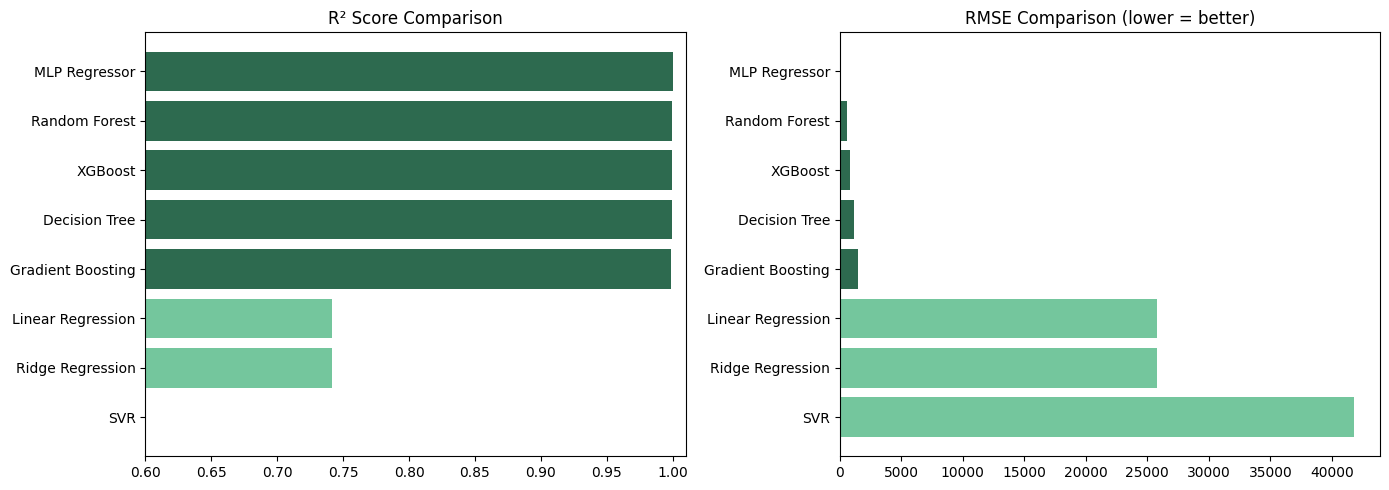

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#2d6a4f" if r > 0.999 else "#74c69d" for r in results_df["R²"]]

axes[0].barh(results_df["Model"], results_df["R²"], color=colors)
axes[0].set_title("R² Score Comparison")
axes[0].set_xlim(0.6, 1.01)
axes[0].invert_yaxis()

axes[1].barh(results_df["Model"], results_df["RMSE"], color=colors)
axes[1].set_title("RMSE Comparison (lower = better)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../models/model_comparison.png", dpi=150)
plt.show()

In [12]:
import joblib
joblib.dump(best_model, "../models/best_model.pkl")
print("Model re-saved with current sklearn version ✓")

Model re-saved with current sklearn version ✓


In [13]:
# Force save XGBoost as best model (as per paper)
xgb_model = models["XGBoost"]
joblib.dump(xgb_model, "../models/best_model.pkl")
print("XGBoost saved as best_model.pkl ✓")

XGBoost saved as best_model.pkl ✓
